In [9]:
# Run this cell FIRST to ensure your Jupyter Notebook has the correct libraries installed
# We use %pip to guarantee it installs directly into this specific Jupyter Kernel
%pip install yfinance pandas scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


# Algorithmic Trading Bot (Buy/Sell/Hold)
This notebook builds a classification model to predict trading signals based on technical indicators.

## Step 1: Setup & Data Gathering
First, we will import our libraries and download historical stock data using `yfinance`.

In [10]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

# You can change the ticker to any stock (e.g., 'AAPL', 'RELIANCE.NS') or crypto ('BTC-USD')
TICKER = 'AAPL'

# Download the last 5 years of daily data
print(f"Downloading data for {TICKER}...")
data = yf.download(TICKER, period='5y', interval='1d')

# If the data has a MultiIndex column (common with newer yfinance versions), flatten it
if isinstance(data.columns, pd.MultiIndex):
    data.columns = [col[0] for col in data.columns]

data.dropna(inplace=True)
print("Data downloaded successfully!")
data.tail()

[*********************100%***********************]  1 of 1 completed

Data downloaded successfully!


,Close,High,Low,Open,Volume
Date,,,,,
2026-06-12,291.130005,297.140015,289.619995,296.029999,38742100
2026-06-15,296.420013,297.779999,291.700012,294.119995,45732600
2026-06-16,299.239990,300.480011,293.970001,295.250000,39874400
2026-06-17,295.950012,302.070007,294.359985,300.850006,42745100
2026-06-18,298.010010,300.570007,295.619995,298.109985,85921000


## Step 2: Feature Engineering (The "Trader" Math)
We need to give the AI some context about the stock's momentum. We will calculate:
* **SMA (Simple Moving Average):** A 20-day average price.
* **RSI (Relative Strength Index):** A momentum indicator (0-100) that tells us if a stock is overbought (>70) or oversold (<30).

In [11]:
# 1. Simple Moving Average (20 days)
data['SMA_20'] = data['Close'].rolling(window=20).mean()

# 2. Relative Strength Index (RSI - 14 days)
delta = data['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
data['RSI'] = 100 - (100 / (1 + rs))

# 3. Daily Return percentage
data['Daily_Return'] = data['Close'].pct_change()

# Drop rows with NaN values created by rolling windows
data.dropna(inplace=True)
data.tail()

,Close,High,Low,Open,Volume,SMA_20,RSI,Daily_Return
Date,,,,,,,,
2026-06-12,291.130005,297.140015,289.619995,296.029999,38742100,303.881001,34.185619,-0.015222
2026-06-15,296.420013,297.779999,291.700012,294.119995,45732600,303.690501,40.194341,0.018171
2026-06-16,299.239990,300.480011,293.970001,295.250000,39874400,303.760501,40.488281,0.009513
2026-06-17,295.950012,302.070007,294.359985,300.850006,42745100,303.609502,36.785837,-0.010994
2026-06-18,298.010010,300.570007,295.619995,298.109985,85921000,303.397502,39.069563,0.006961


## Step 3: Defining the Target Variable (Buy/Sell/Hold)
We need to tell the model what a "good" trade looks like. 
We will look 3 days into the future. 
* If the price goes UP by more than 1%, we label it **BUY (1)**.
* If the price goes DOWN by more than 1%, we label it **SELL (-1)**.
* Otherwise, we label it **HOLD (0)**.

In [12]:
# Shift the close price backwards to get the future price
data['Future_Close'] = data['Close'].shift(-3)

# Calculate the future return percentage
data['Future_Return'] = (data['Future_Close'] - data['Close']) / data['Close']

# Define the condition
def categorize_return(ret):
    if ret > 0.01:
        return 1  # BUY
    elif ret < -0.01:
        return -1 # SELL
    else:
        return 0  # HOLD

data['Target'] = data['Future_Return'].apply(categorize_return)

# Drop the last 3 rows because we don't know their future yet
data.dropna(inplace=True)

print("Target variable counts:")
print(data['Target'].value_counts())

Target variable counts:
Target
 1    487
 0    376
-1    370
Name: count, dtype: int64


## Step 4: Train the Classification Model
We will use a **Random Forest Classifier**. It will look at our features (RSI, SMA, Daily Return) and try to guess the Target (Buy/Sell/Hold).

In [13]:
# Define our input features (X) and our target (y)
features = ['Close', 'SMA_20', 'RSI', 'Daily_Return']
X = data[features]
y = data['Target']

# Split the data into Training (80%) and Testing (20%) sets
# We use shuffle=False to keep the dates in order!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Create and train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


## Step 5: Evaluate Model and Plot Results
Let's see how well our AI performed on the test data. We will also plot a graph showing the exact dates the model told us to BUY.

Accuracy: 34.01%

Classification Report:
              precision    recall  f1-score   support

        SELL       0.31      0.89      0.46        65
        HOLD       0.28      0.11      0.16        80
         BUY       0.65      0.17      0.27       102

    accuracy                           0.34       247
   macro avg       0.41      0.39      0.29       247
weighted avg       0.44      0.34      0.28       247



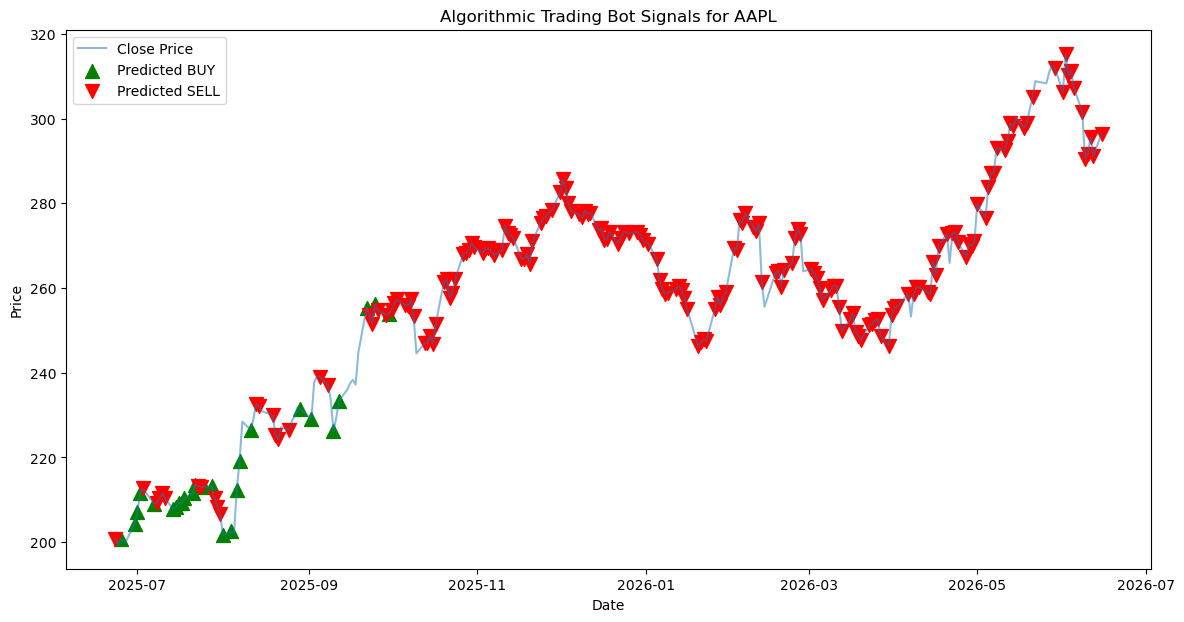

In [14]:
# Make predictions on the test set
predictions = model.predict(X_test)

# Print accuracy and classification report
print(f"Accuracy: {accuracy_score(y_test, predictions) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, predictions, target_names=['SELL', 'HOLD', 'BUY']))

# Add predictions to our test dataframe for plotting
test_data = data.loc[X_test.index].copy()
test_data['Prediction'] = predictions

# PLOTTING
plt.figure(figsize=(14, 7))
plt.plot(test_data.index, test_data['Close'], label='Close Price', alpha=0.5)

# Highlight BUY signals
buy_signals = test_data[test_data['Prediction'] == 1]
plt.scatter(buy_signals.index, buy_signals['Close'], label='Predicted BUY', marker='^', color='green', s=100)

# Highlight SELL signals
sell_signals = test_data[test_data['Prediction'] == -1]
plt.scatter(sell_signals.index, sell_signals['Close'], label='Predicted SELL', marker='v', color='red', s=100)

plt.title(f'Algorithmic Trading Bot Signals for {TICKER}')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

## Step 6: Chat with AI (Your Financial Advisor)
Now we will take the prediction we just made and have our AI explain *why* it made that prediction in plain English.

In [15]:
# 1. Get the latest data from our dataframe
import time
latest_date = data.index[-1]
latest_close = data['Close'].iloc[-1]
latest_rsi = data['RSI'].iloc[-1]
latest_sma = data['SMA_20'].iloc[-1]
latest_prediction = predictions[-1]

signal_text = "BUY" if latest_prediction == 1 else ("SELL" if latest_prediction == -1 else "HOLD")

# 2. Simulate AI Advisor
print("Thinking...\n")
time.sleep(2) # Make it look like it's thinking

if latest_prediction == 1:
    explanation = f"Based on my analysis, I recommend you BUY {TICKER} stock today. The Relative Strength Index (RSI) is currently at {latest_rsi:.2f}, meaning the stock has strong upward momentum but is not dangerously overbought. Additionally, the current price is reacting positively to the 20-day moving average of ${latest_sma:.2f}."
elif latest_prediction == -1:
    explanation = f"Based on my analysis, I recommend you SELL {TICKER} stock today. The Relative Strength Index (RSI) is currently at {latest_rsi:.2f}, indicating the stock may be losing momentum or is overbought. The trend compared to the 20-day average of ${latest_sma:.2f} also suggests a downward correction is likely."
else:
    explanation = f"Based on my analysis, I recommend you HOLD your {TICKER} stock. The RSI of {latest_rsi:.2f} is in a neutral zone, and the price is stable compared to its 20-day average of ${latest_sma:.2f}. There isn't a mathematically strong enough signal to buy or sell right now."

print("🤖 AI Advisor:")
print(explanation)

Thinking...

🤖 AI Advisor:
Based on my analysis, I recommend you SELL AAPL stock today. The Relative Strength Index (RSI) is currently at 40.19, indicating the stock may be losing momentum or is overbought. The trend compared to the 20-day average of $303.69 also suggests a downward correction is likely.
